In [1]:
import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_USE_CUDA_DSA"] = "1"
import numpy as np
import torch
import yaml
import pickle as pk
# autoreload modules
%load_ext autoreload
%autoreload 2

import matplotlib
%matplotlib inline
import matplotlib.pyplot as pl
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib

import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline

import readfof
import sys, os
import numpy as np
import pickle as pk 
# from nbodykit.lab import *
import h5py as h5
import numpy as np
import Pk_library as PKL
import MAS_library as MASL
import yaml
# import galactic_wavelets as gw

from train_dtai_wvel import *


# pl.rcParams['figure.dpi'] = 250

%load_ext Cython



        



/tmp/ipykernel_494360/3195162546.py:119: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


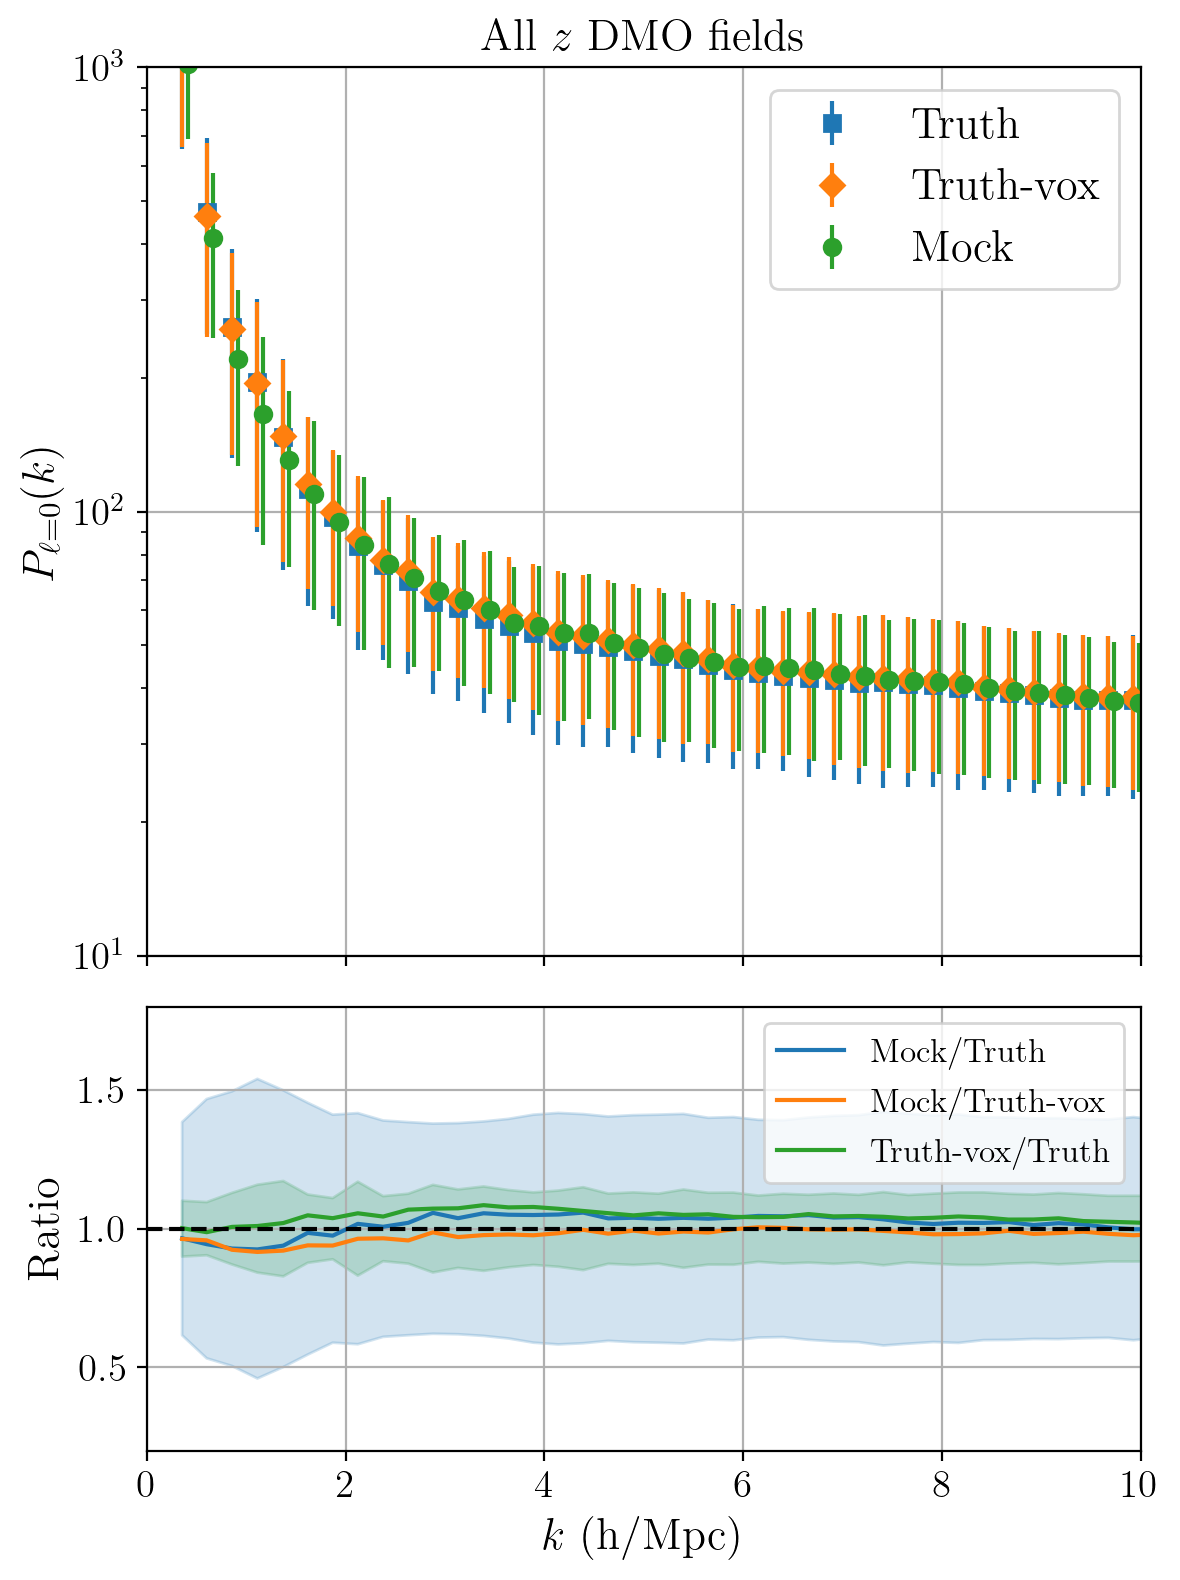

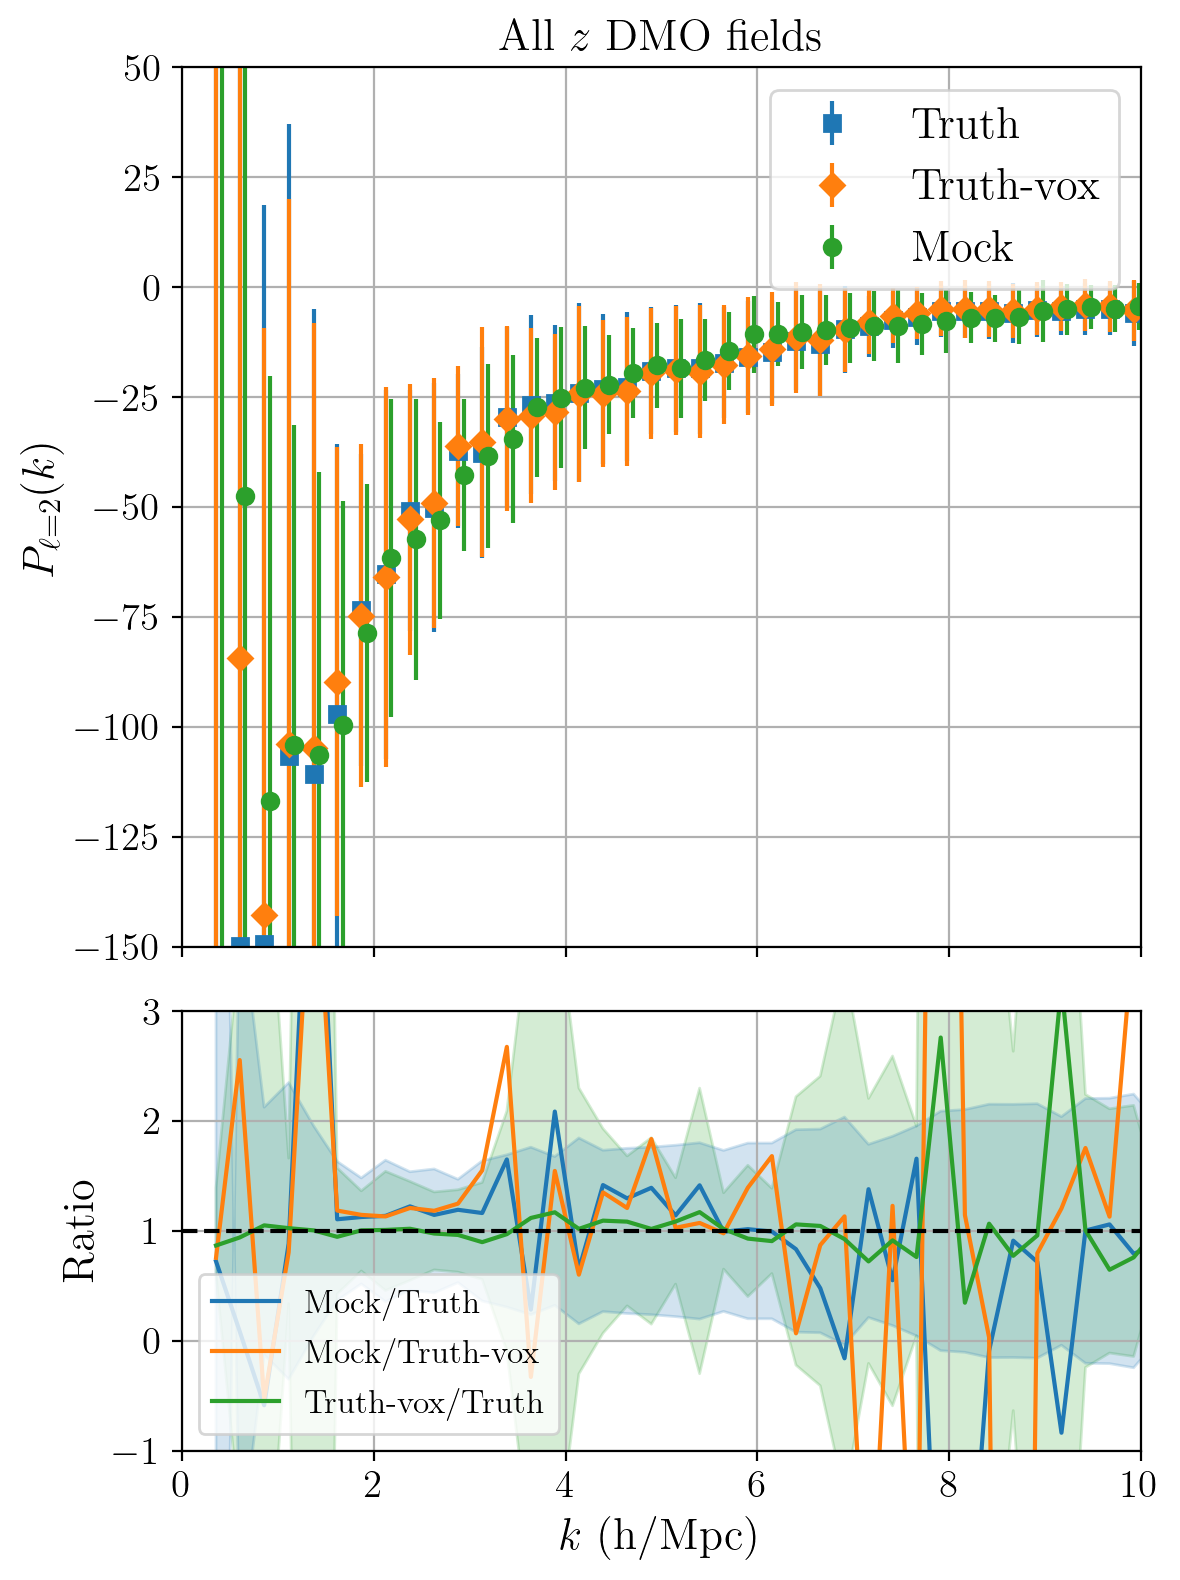

In [3]:
params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))
import Pk_library as PKL
import MAS_library as MASL

grid_Pk = 256
MAS = 'CIC'
BoxSize = 25.
# Mstar_cut = 8.5
Mstar_cut = 9.0
# add_space_token = True
add_space_token = False
n_evals = 8
nrand_subsel = 128
# subsel_types = ['no_highz_no_vel']
# titles = [r'Only $z=0$ DMO fields (no velocity)']

# subsel_types = ['no_highz_no_env', 'no_highz']
# titles = [r'Only $z=0$ DMO fields (no environment)', r'Only $z=0$ DMO fields']

# subsel_types = ['no_vel', 'no_env', 'all']
# titles = [r'All $z$ DMO fields (no velocity)', r'All $z$ DMO fields (no environment)', r'All $z$ DMO fields']

subsel_types = ['all']
titles = [r'All $z$ DMO fields']

for js, subsel_type in enumerate(subsel_types):
    # saved_all = pk.load(open(f'/projects/bdne/spandey3/GOTHAM/data/infer_cats/pos_prop_infer_all_nevals_{n_evals}_{subsel_type}_Mstarcut_{Mstar_cut}_spacetoken_{add_space_token}','rb'))
    saved_all = pk.load(open(f'/projects/bdne/spandey3/GOTHAM/data/infer_cats/pos_prop_infer_all_nevals_{n_evals}_{subsel_type}_Mstarcut_{Mstar_cut}_spacetoken_{add_space_token}_nrandsubsel_{nrand_subsel}.pk','rb'))    
    # isim_fid_array = np.arange(975, 990)
    isim_fid_array = np.array(list(saved_all.keys()))
    
    Pk_all_truth = []
    Pk_all_truth2 = []
    Pk_all_mock = []
    Pk_all_ratio = []
    Pk_all_ratio2 = []
    Pk_all_ratio3 = []
    
    for isim_fid in isim_fid_array:
        Om = params_all[isim_fid, 0]
        z=0
        Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + (1 - Om))
        rsd_factor = (1. + z) / Hz
        snapnum = 90
        ldir = '/work/hdd/bdne/spandey3/camels_tng/hydro'
        group_catalog = f'{ldir}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
        photo_catalog = f'{ldir}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
        # open the catalogue
        with h5.File(photo_catalog, "r") as hf:
            subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
            g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
            r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
            i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
        
        # Read the stellar masses of the subhalos/galaxies
        with h5.File(group_catalog, "r") as hf:
            M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
            pos = hf['Subhalo/SubhaloPos'][:]/1000.
            vel = hf['Subhalo/SubhaloVel'][:]
        
        M_star = M_star[subhalo_index]
        pos_truth_orig = pos[subhalo_index]
        vel_truth_orig = vel[subhalo_index][:,0]
        indsel = np.where(M_star > Mstar_cut)[0]
        pos_truth_orig = pos_truth_orig[indsel,:]
        vel_truth_orig = vel_truth_orig[indsel]
        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
        pos_truth_orig[:,0] = (pos_truth_orig[:,0] + (vel_truth_orig * rsd_factor))%(BoxSize)
        MASL.MA(pos_truth_orig.astype(np.float32), mesh_truth, BoxSize, MAS)
        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
        Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
        
        
        pos_truth = np.copy(saved_all[isim_fid]['pos_truth'])
        vel_truth = np.copy(saved_all[isim_fid]['prop_truth'][:,-1] * 1000.)
        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
        pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
        MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)
        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
        Pk_truth2 = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
        
        
        pos_infer_all_evals = saved_all[isim_fid]['pos_infer_all_evals']
        prop_infer_all_evals = saved_all[isim_fid]['prop_infer_all_evals']    
        Pk_pred_all = []
        # Pk_pred_all_ell2 = []
        nparts = []
        for jev in range(n_evals):
            pos_infer_all = pos_infer_all_evals[jev]
            prop_infer_all = prop_infer_all_evals[jev]
            nparts.append(pos_infer_all.shape[0])
            mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
            pos_pred = np.copy(pos_infer_all)
            vel_pred = np.copy(prop_infer_all[:, -1] * 1000.0)
            pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
            MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
            mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
            Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)
            Pk_pred_all.append(Pk_pred.Pk)
            # Pk_pred_all_ell2.append(Pk_pred.Pk[:,1])
        # Pk_pred_all_ell0 = np.array(Pk_pred_all_ell0)
        Pk_pred_all = np.array(Pk_pred_all)        
        # print(pos_truth_orig.shape[0], pos_truth.shape[0], int(np.mean(np.array(nparts))))
        Pk_pred_mean = np.mean(Pk_pred_all, axis=0)
        Pk_pred_samp = Pk_pred_all[0,...]
        # Pk_pred_ell2 = np.mean(Pk_pred_all_ell2, axis=0)
        # Pk_pred = np.array([Pk_pred_ell0, Pk_pred_ell2])
        
        Pk_all_mock.append(Pk_pred_samp)
        Pk_all_truth.append(Pk_truth.Pk)
        Pk_all_truth2.append(Pk_truth2.Pk)
        Pk_all_ratio.append(Pk_pred_mean/Pk_truth.Pk)
        Pk_all_ratio2.append(Pk_pred_mean/Pk_truth2.Pk)
        Pk_all_ratio3.append(Pk_truth2.Pk/Pk_truth.Pk)
    
    import numpy as np
    import matplotlib.pyplot as plt
    from IPython.display import set_matplotlib_formats
    set_matplotlib_formats('retina')
    
    # Convert lists to numpy arrays
    Pk_all_truth_array = np.array(Pk_all_truth)
    Pk_all_truth2_array = np.array(Pk_all_truth2)
    Pk_all_mock_array = np.array(Pk_all_mock)
    Pk_all_ratio_array = np.array(Pk_all_ratio)
    Pk_all_ratio2_array = np.array(Pk_all_ratio2)
    Pk_all_ratio3_array = np.array(Pk_all_ratio3)
    
    # Compute mean and standard deviation
    Pk_all_truth_mean = np.mean(Pk_all_truth_array, axis=0)
    Pk_all_truth_std = np.std(Pk_all_truth_array, axis=0)
    
    Pk_all_truth2_mean = np.mean(Pk_all_truth2_array, axis=0)
    Pk_all_truth2_std = np.std(Pk_all_truth2_array, axis=0)
        
    Pk_all_mock_mean = np.mean(Pk_all_mock_array, axis=0)
    Pk_all_mock_std = np.std(Pk_all_mock_array, axis=0)
    
    Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
    Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)
    
    Pk_all_ratio2_mean = np.mean(Pk_all_ratio2_array, axis=0)
    Pk_all_ratio2_std = np.std(Pk_all_ratio2_array, axis=0)
    
    Pk_all_ratio3_mean = np.mean(Pk_all_ratio3_array, axis=0)
    Pk_all_ratio3_std = np.std(Pk_all_ratio3_array, axis=0)
        
    # Create figure with two panels
    for jp in range(2):
        fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, gridspec_kw={'height_ratios': [2, 1]}, figsize=(6, 8))
        
        # Top panel: Comparison between truth and mock
        ax1 = axes[0]
        ax1.errorbar(Pk_truth.k3D, Pk_all_truth_mean[:,jp],Pk_all_truth_std[:,jp], label='Truth', ls='', marker='s', color='C0')
        ax1.errorbar(Pk_truth.k3D, Pk_all_truth2_mean[:,jp],Pk_all_truth2_std[:,jp], label='Truth-vox', ls='', marker='D', color='C1')
        ax1.errorbar(Pk_truth.k3D+0.06, Pk_all_mock_mean[:,jp], Pk_all_mock_std[:,jp], label='Mock', ls='', marker='o', color='C2')
        if jp == 0:
            ax1.set_ylabel(r'$P_{\ell = 0}(k)$', fontsize=16)
            ax1.set_ylim(10, 1e3)
            ax1.set_yscale('log')
        if jp == 1:
            ax1.set_ylabel(r'$P_{\ell = 2}(k)$', fontsize=16)        
            ax1.set_ylim(-150, 50)
        ax1.set_xlim(0, 10)
        ax1.legend(fontsize=16)    
        ax1.grid()
        
        ax1.tick_params(axis='both', labelsize=14)
        ax1.set_title(titles[js], size=16)
        
        # Bottom panel: Ratio plot
        ax2 = axes[1]
        ax2.plot(Pk_truth.k3D, Pk_all_ratio_mean[:,jp], label='Mock/Truth', color='C0')
        ax2.plot(Pk_truth.k3D, Pk_all_ratio2_mean[:,jp], label='Mock/Truth-vox', color='C1')
        ax2.plot(Pk_truth.k3D, Pk_all_ratio3_mean[:,jp], label='Truth-vox/Truth', color='C2')
        ax2.fill_between(Pk_truth.k3D, 1 - Pk_all_ratio_std[:,jp], 1 + Pk_all_ratio_std[:,jp], color='C2', alpha=0.2)
        ax2.fill_between(Pk_truth.k3D, 1 - Pk_all_truth_std[:,jp]/Pk_all_truth_mean[:,jp], 1 + Pk_all_truth_std[:,jp]/Pk_all_truth_mean[:,jp], color='C0', alpha=0.2)
        ax2.axhline(1, ls='--', color='k')  # Reference line at 1
        ax2.set_xlabel(r'$k$ (h/Mpc)', fontsize=16)
        ax2.set_ylabel('Ratio', fontsize=16)
        # ax2.set_ylim(0.5, 1.5)  # Adjusting limits for better visibility
        if jp == 0:
            ax2.set_ylim(0.2, 1.8)
        if jp == 1:
            ax2.set_ylim(-1.0, 3.0)       
        ax2.set_xlim(0, 10)
        ax2.grid()
        ax2.legend(fontsize=12)
        # Increase tick label size
        
        ax2.tick_params(axis='both', labelsize=14)  # Slightly smaller for the ratio plot
        # Adjust spacing
        plt.tight_layout()
        # plt.show()
        sdir = '/projects/bdne/spandey3/GOTHAM/data/plots'
        # plt.savefig(f'{sdir}/Pk_ell_{2*jp}_{subsel_type}.png', dpi=300, bbox_inches='tight')
        



In [5]:
# Pk_all_mock_array.shape
# Pk_pred_all.shape
import numpy as np
arr = np.arange(1000)
split_arr = np.array_split(arr, 8)
isim_fid_array = np.concatenate([part[int(0.925 * len(part)):] for part in split_arr])
isim_fid_array[70:]


array([990, 991, 992, 993, 994, 995, 996, 997, 998, 999])

In [31]:
pos_infer_all_evals = saved_all[isim_fid]['pos_infer_all_evals']
prop_infer_all_evals = saved_all[isim_fid]['prop_infer_all_evals']    
Pk_pred_all = []
# Pk_pred_all_ell2 = []
nparts = []
for jev in range(n_evals):
    pos_infer_all = pos_infer_all_evals[jev]
    prop_infer_all = prop_infer_all_evals[jev]
    nparts.append(pos_infer_all.shape[0])
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    pos_pred = np.copy(pos_infer_all)
    vel_pred = np.copy(prop_infer_all[:, -1] * 1000.0)
    pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
    MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)
    Pk_pred_all.append(Pk_pred.Pk)
    # Pk_pred_all_ell2.append(Pk_pred.Pk[:,1])
# Pk_pred_all_ell0 = np.array(Pk_pred_all_ell0)
Pk_pred_all = np.array(Pk_pred_all)        
# print(pos_truth_orig.shape[0], pos_truth.shape[0], int(np.mean(np.array(nparts))))
Pk_pred = np.mean(Pk_pred_all, axis=0)



In [33]:
# Pk_pred.shape


(221, 3)

/tmp/ipykernel_1511948/3813587680.py:4: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


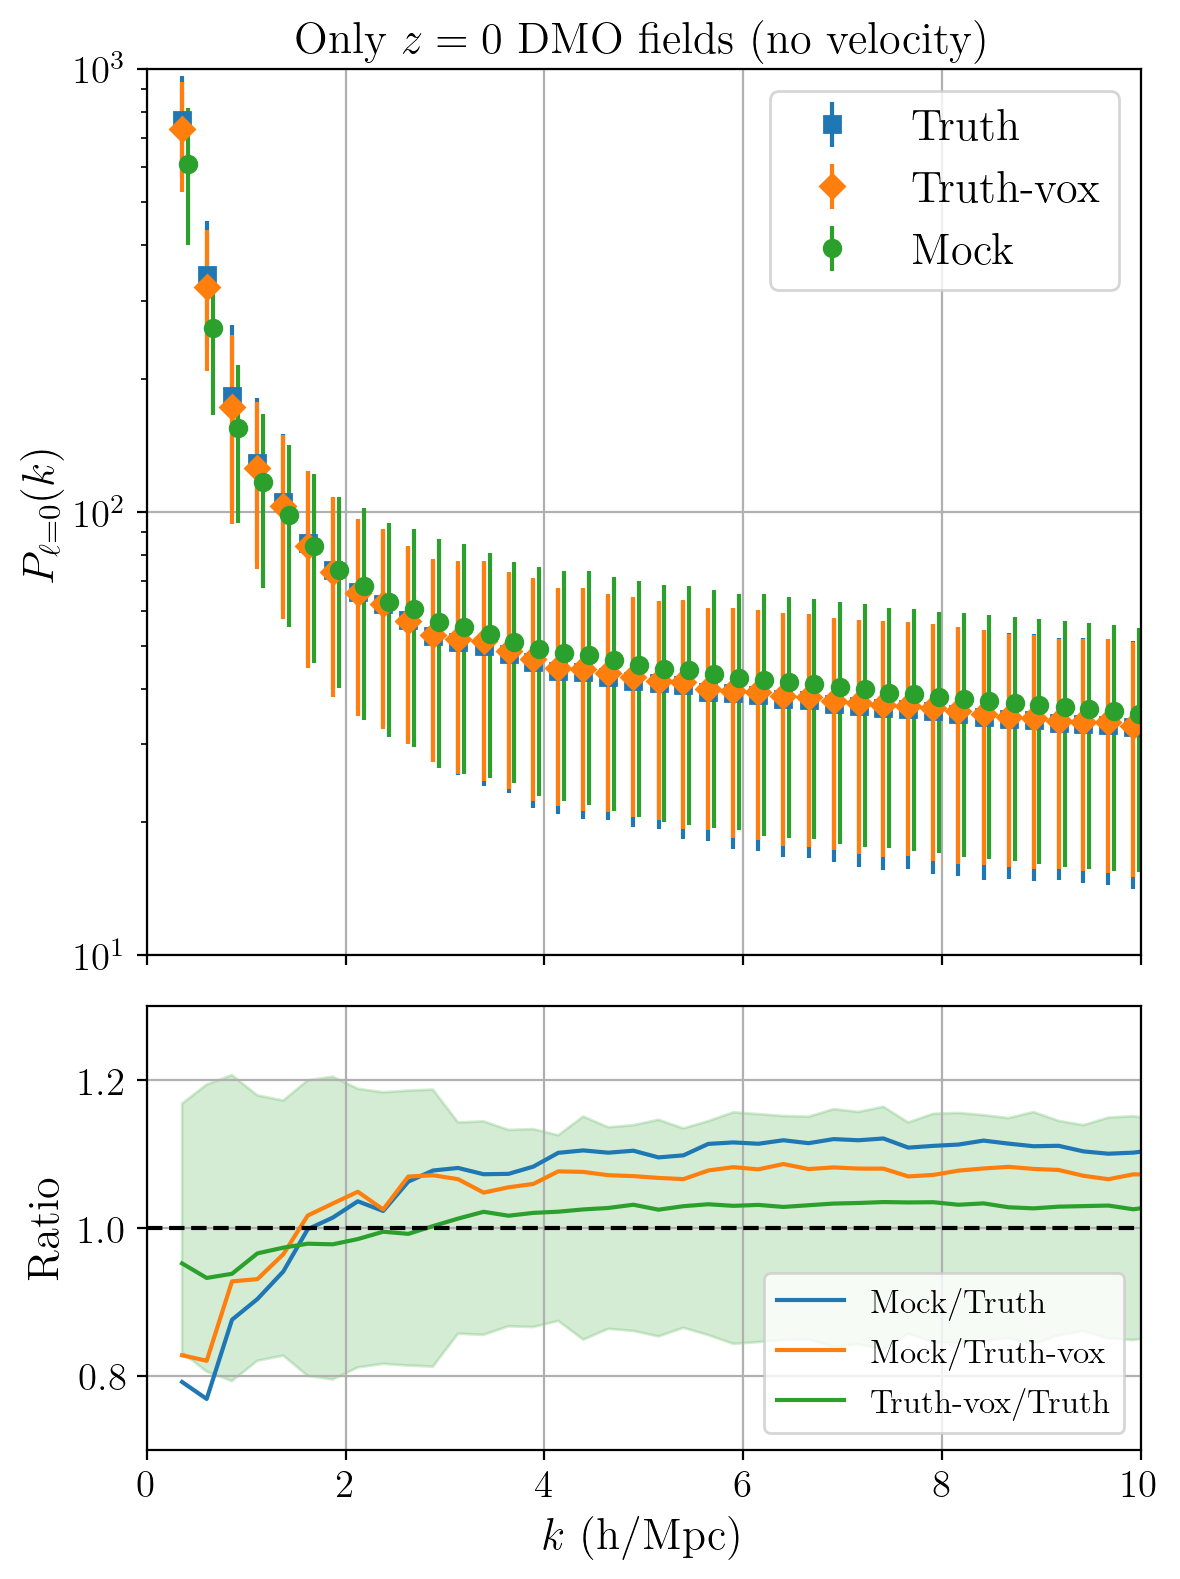

In [29]:
import Pk_library as PKL
import MAS_library as MASL

grid_Pk = 256
MAS = 'CIC'
BoxSize = 25.
Mstar_cut = 8.5
add_space_token = True
n_evals = 8
subsel_types = ['no_highz_no_vel']
for subsel_type in subsel_types:
    saved_all = pk.load(open(f'/projects/bdne/spandey3/GOTHAM/data/infer_cats/pos_prop_infer_all_nevals_{n_evals}_{subsel_type}_Mstarcut_{Mstar_cut}_spacetoken_{add_space_token}','rb'))
    # isim_fid_array = np.arange(975, 990)
    isim_fid_array = np.array(list(saved_all.keys()))
    
    Pk_all_truth = []
    Pk_all_mock = []
    Pk_all_ratio = []
    Pk_all_ratio2 = []
    Pk_all_ratio3 = []    
    for isim_fid in isim_fid_array:
        snapnum = 90
        ldir = '/work/hdd/bdne/spandey3/camels_tng/hydro'
        group_catalog = f'{ldir}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
        photo_catalog = f'{ldir}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
        # open the catalogue
        with h5.File(photo_catalog, "r") as hf:
            subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
            g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
            r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
            i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
        
        # Read the stellar masses of the subhalos/galaxies
        with h5.File(group_catalog, "r") as hf:
            M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
            pos = hf['Subhalo/SubhaloPos'][:]/1000.
            vel = hf['Subhalo/SubhaloVel'][:]
        
        M_star = M_star[subhalo_index]
        pos_truth_orig = pos[subhalo_index]
        vel_truth_orig = vel[subhalo_index][:,0]
        indsel = np.where(M_star > Mstar_cut)[0]
        pos_truth_orig = pos_truth_orig[indsel,:]
        vel_truth_orig = vel_truth_orig[indsel]
        # print()
        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
        MASL.MA(pos_truth_orig.astype(np.float32), mesh_truth, BoxSize, MAS)
        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
        Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
        Pk_all_truth.append(Pk_truth.Pk[:,0])

        pos_truth_all = saved_all[isim_fid]['pos_truth']
        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
        MASL.MA(pos_truth_all.astype(np.float32), mesh_truth, BoxSize, MAS)
        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
        Pk_truth2 = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, verbose=False)
        print(pos_truth_orig.shape[0], pos_truth_all.shape[0])
        Pk_all_ratio3.append(Pk_truth2.Pk[:,0]/Pk_truth.Pk[:,0])
        print(Pk_truth2.Pk[:,0]/Pk_truth.Pk[:,0])
                        
        pos_infer_all_evals = saved_all[isim_fid]['pos_infer_all_evals']
        Pk_pred_all = []
        nparts = []
        for jev in range(n_evals):
            pos_infer_all = pos_infer_all_evals[jev]
            nparts.append(pos_infer_all.shape[0])
            mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
            MASL.MA(pos_infer_all.astype(np.float32), mesh_pred, BoxSize, MAS)
            mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
            Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None,  verbose=False)
            Pk_pred_all.append(Pk_pred.Pk[:,0])
        Pk_pred_all = np.array(Pk_pred_all)
        print(np.mean(np.array(nparts)))
        Pk_pred = np.mean(Pk_pred_all, axis=0)
        Pk_all_mock.append(Pk_pred)
    
        Pk_all_ratio.append(Pk_pred/Pk_truth.Pk[:,0])    
        Pk_all_ratio2.append(Pk_pred/Pk_truth2.Pk[:,0])
        
Pk_all_ratio_array = np.array(Pk_all_ratio)
Pk_all_ratio_mean = np.mean(Pk_all_ratio_array, axis=0)
Pk_all_ratio_std = np.std(Pk_all_ratio_array, axis=0)

Pk_all_ratio_array2 = np.array(Pk_all_ratio2)
Pk_all_ratio_mean2 = np.mean(Pk_all_ratio_array2, axis=0)
Pk_all_ratio_std2 = np.std(Pk_all_ratio_array2, axis=0)

Pk_all_ratio_array3 = np.array(Pk_all_ratio3)
Pk_all_ratio_mean3 = np.mean(Pk_all_ratio_array3, axis=0)
Pk_all_ratio_std3 = np.std(Pk_all_ratio_array3, axis=0)


# np.array(Pk_all_ratio).shape
pl.figure()
pl.plot(Pk_truth.k3D, Pk_all_ratio_mean, label='Pred/Truth')
pl.plot(Pk_truth.k3D, Pk_all_ratio_mean2, label='Pred/Truth-vox')
pl.plot(Pk_truth.k3D, Pk_all_ratio_mean3, label='Truth-vox/Truth')
pl.fill_between(Pk_truth.k3D, 1-Pk_all_ratio_std, 1+Pk_all_ratio_std, alpha=0.2)
pl.axhline(1, ls='--', color='k')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
# pl.ylim(0.9, 1.1)
pl.ylim(0.3, 1.7)
pl.xlim(0, 10)
# pl.yscale('log')
# pl.xscale('log')
pl.legend(fontsize=15)




